# 得点直前の得点差別・得点間隔（待ち時間）の経験的分析

`statsbomb_data` 以下の全リーグ・全シーズンの `*_goals_and_red_cards.csv` を対象に、

- **得点チームから見た、その得点が入る直前の得点差**（-5〜5の各値、6以上、-6以下の13区分）ごとに、
- **直前の得点（どちらのチームによるものでも良い）からその得点が入るまでの待ち時間**

の分布をヒストグラムにする。試合開始から最初の得点までは、キックオフ（t=0）からの経過時間を
待ち時間として扱う。

- 入力：`statsbomb_data/**/*_goals_and_red_cards.csv`（全リーグ・全シーズン）
- 出力：13区分（+ 6以上／-6以下を個別に拡大した図）のヒストグラム画像


## データ形式・前提

各 `goals_and_red_cards.csv` は1行が「得点」または「退場」のイベント（+試合ごとの
プレースホルダー行）を表す。本分析で使うのは得点イベントの行のみ（`red_card` が欠損かつ
`home_away` が非欠損の行）。

| 列名 | 内容 |
|---|---|
| `match_id` | 試合ID（`league_code`, `season_name` と組み合わせて一意に試合を識別する） |
| `home_away` | 得点したチーム（0=home, 1=away） |
| `minute` / `second` | 得点した実時刻（試合クロック、前半・後半を通して連続的に増加する分・秒） |

**時間の単位について**: Dixon&Robinsonモデルで使った `dr_time` はアディショナルタイムを
[0, 0.5], [0, 1.0] に圧縮した正規化時刻だったが、本分析では実際の経過時間（分）を見たいため
`dr_time` は使わず、`minute + second/60` をそのまま「試合クロック上の経過時間（分）」として使う。


In [11]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# グラフ内の日本語（タイトル・軸ラベル等）が文字化けしないよう、macOS標準の日本語フォントを指定する。
# （Windows等、別環境で開く場合は "Meiryo" や "Yu Gothic" などお使いの環境にある日本語フォント名に変更してください）
plt.rcParams["font.family"] = "Hiragino Sans"
plt.rcParams["axes.unicode_minus"] = False


## 1. 全リーグ・全シーズンのデータを読み込む

`match_id` はデータセット全体で一意であることを確認済みだが、念のため
`league_code, season_name, match_id` の組をキーとして試合を識別する。


In [12]:
DATA_DIR = "../../statsbomb_data"

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*_goals_and_red_cards.csv"), recursive=True))
print(f"{len(csv_paths)} 件のファイルが見つかりました")

df_all = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"行数: {len(df_all)}, 試合数: {df_all['match_id'].nunique()}")


11 件のファイルが見つかりました
行数: 10048, 試合数: 2461


## 2. 試合ごとに「得点直前の得点差」と「直前の得点からの待ち時間」を計算する

試合ごとに得点イベントを時刻順に並べ、各得点について

- `diff_before`: 得点したチームから見た、その得点が入る直前の得点差（得点チームの得点 − 相手の得点）
- `waiting_time`: 直前の得点（試合最初の得点なら試合開始 t=0）からこの得点までの経過時間（分）

を記録する。退場者の行は無視する（得点イベントのみを対象とする）。


In [13]:
def build_goal_events(df):
    """
    goals_and_red_cards の df（複数リーグ・シーズンを結合したものでも可）から、
    得点イベントごとの diff_before（得点チーム視点の得点直前の得点差）と
    waiting_time（直前の得点からの経過時間・分）を計算する。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        home_score = away_score = 0
        prev_t = 0.0  # 試合開始（キックオフ）
        for row in g.itertuples(index=False):
            t = row.time_min
            if row.home_away == 0:
                diff_before = home_score - away_score
                home_score += 1
            else:
                diff_before = away_score - home_score
                away_score += 1
            records.append({
                "league_code": league_code,
                "season_name": season_name,
                "match_id": match_id,
                "diff_before": diff_before,
                "waiting_time": t - prev_t,
            })
            prev_t = t

    return pd.DataFrame(records)


events_df = build_goal_events(df_all)
print(f"得点イベント数: {len(events_df)}")
events_df.head()


得点イベント数: 6964


,league_code,season_name,match_id,diff_before,waiting_time
0,FB,2023/2024,3910730,0,6.000000
1,FB,2023/2024,3910730,-1,14.100000
2,FB,2023/2024,3910730,0,69.766667
3,FB,2023/2024,3910730,-1,6.733333
4,FB,2023/2024,3910731,0,17.016667


## 3. 得点差を13区分に分類する

得点直前の得点差を、-5〜5の各値（11区分）＋「6以上」＋「-6以下」の合計13区分に分類する。


In [14]:
def categorize_diff(d):
    if d <= -6:
        return "-6以下"
    if d >= 6:
        return "6以上"
    return str(int(d))


CATEGORY_ORDER = ["-6以下"] + [str(i) for i in range(-5, 6)] + ["6以上"]

events_df["diff_category"] = events_df["diff_before"].apply(categorize_diff)
events_df["diff_category"].value_counts().reindex(CATEGORY_ORDER)


diff_category
-6以下       7
-5         8
-4        32
-3       108
-2       362
-1      1066
0       2945
1       1355
2        604
3        272
4        111
5         54
6以上       40
Name: count, dtype: int64

## 4. ヒストグラムの区分（ビン）を全グラフで共通化する

待ち時間（分）のヒストグラムのビン幅は5分刻みとし、全体（13区分すべて）の最大待ち時間から
上限を決めることで、全てのグラフで同じビン境界を使う。

**最頻値（モード）について**: 待ち時間は連続量なので、単純な「最も多い値」は定義できない。
そのため、このヒストグラムのビンの中で度数が最大となるビンの中央値を「最頻値」として表示する
（このヒストグラム上のビン幅に依存する近似的な値であることに注意）。


In [15]:
BIN_WIDTH = 5  # 分
max_wait = events_df["waiting_time"].max()
BIN_EDGES = np.arange(0, np.ceil(max_wait / BIN_WIDTH) * BIN_WIDTH + BIN_WIDTH, BIN_WIDTH)
print(f"最大待ち時間: {max_wait:.2f}分 -> ビン境界: 0〜{BIN_EDGES[-1]:.0f}分（{BIN_WIDTH}分刻み、{len(BIN_EDGES)-1}ビン）")


最大待ち時間: 94.78分 -> ビン境界: 0〜95分（5分刻み、19ビン）


## 5. 13区分すべてのヒストグラムを1枚の図にまとめて描画・保存する

各パネルに
- 標本数 `n`
- 平均値（実線）
- 中央値（破線）
- 最頻値（点線、上のビンベースの近似値）

を重ねて表示する。ビン幅・ビン境界は全パネル共通（縦軸のスケールはパネルごとに自動調整）。


保存しました: ./figures/score_difference_histograms_all13.png


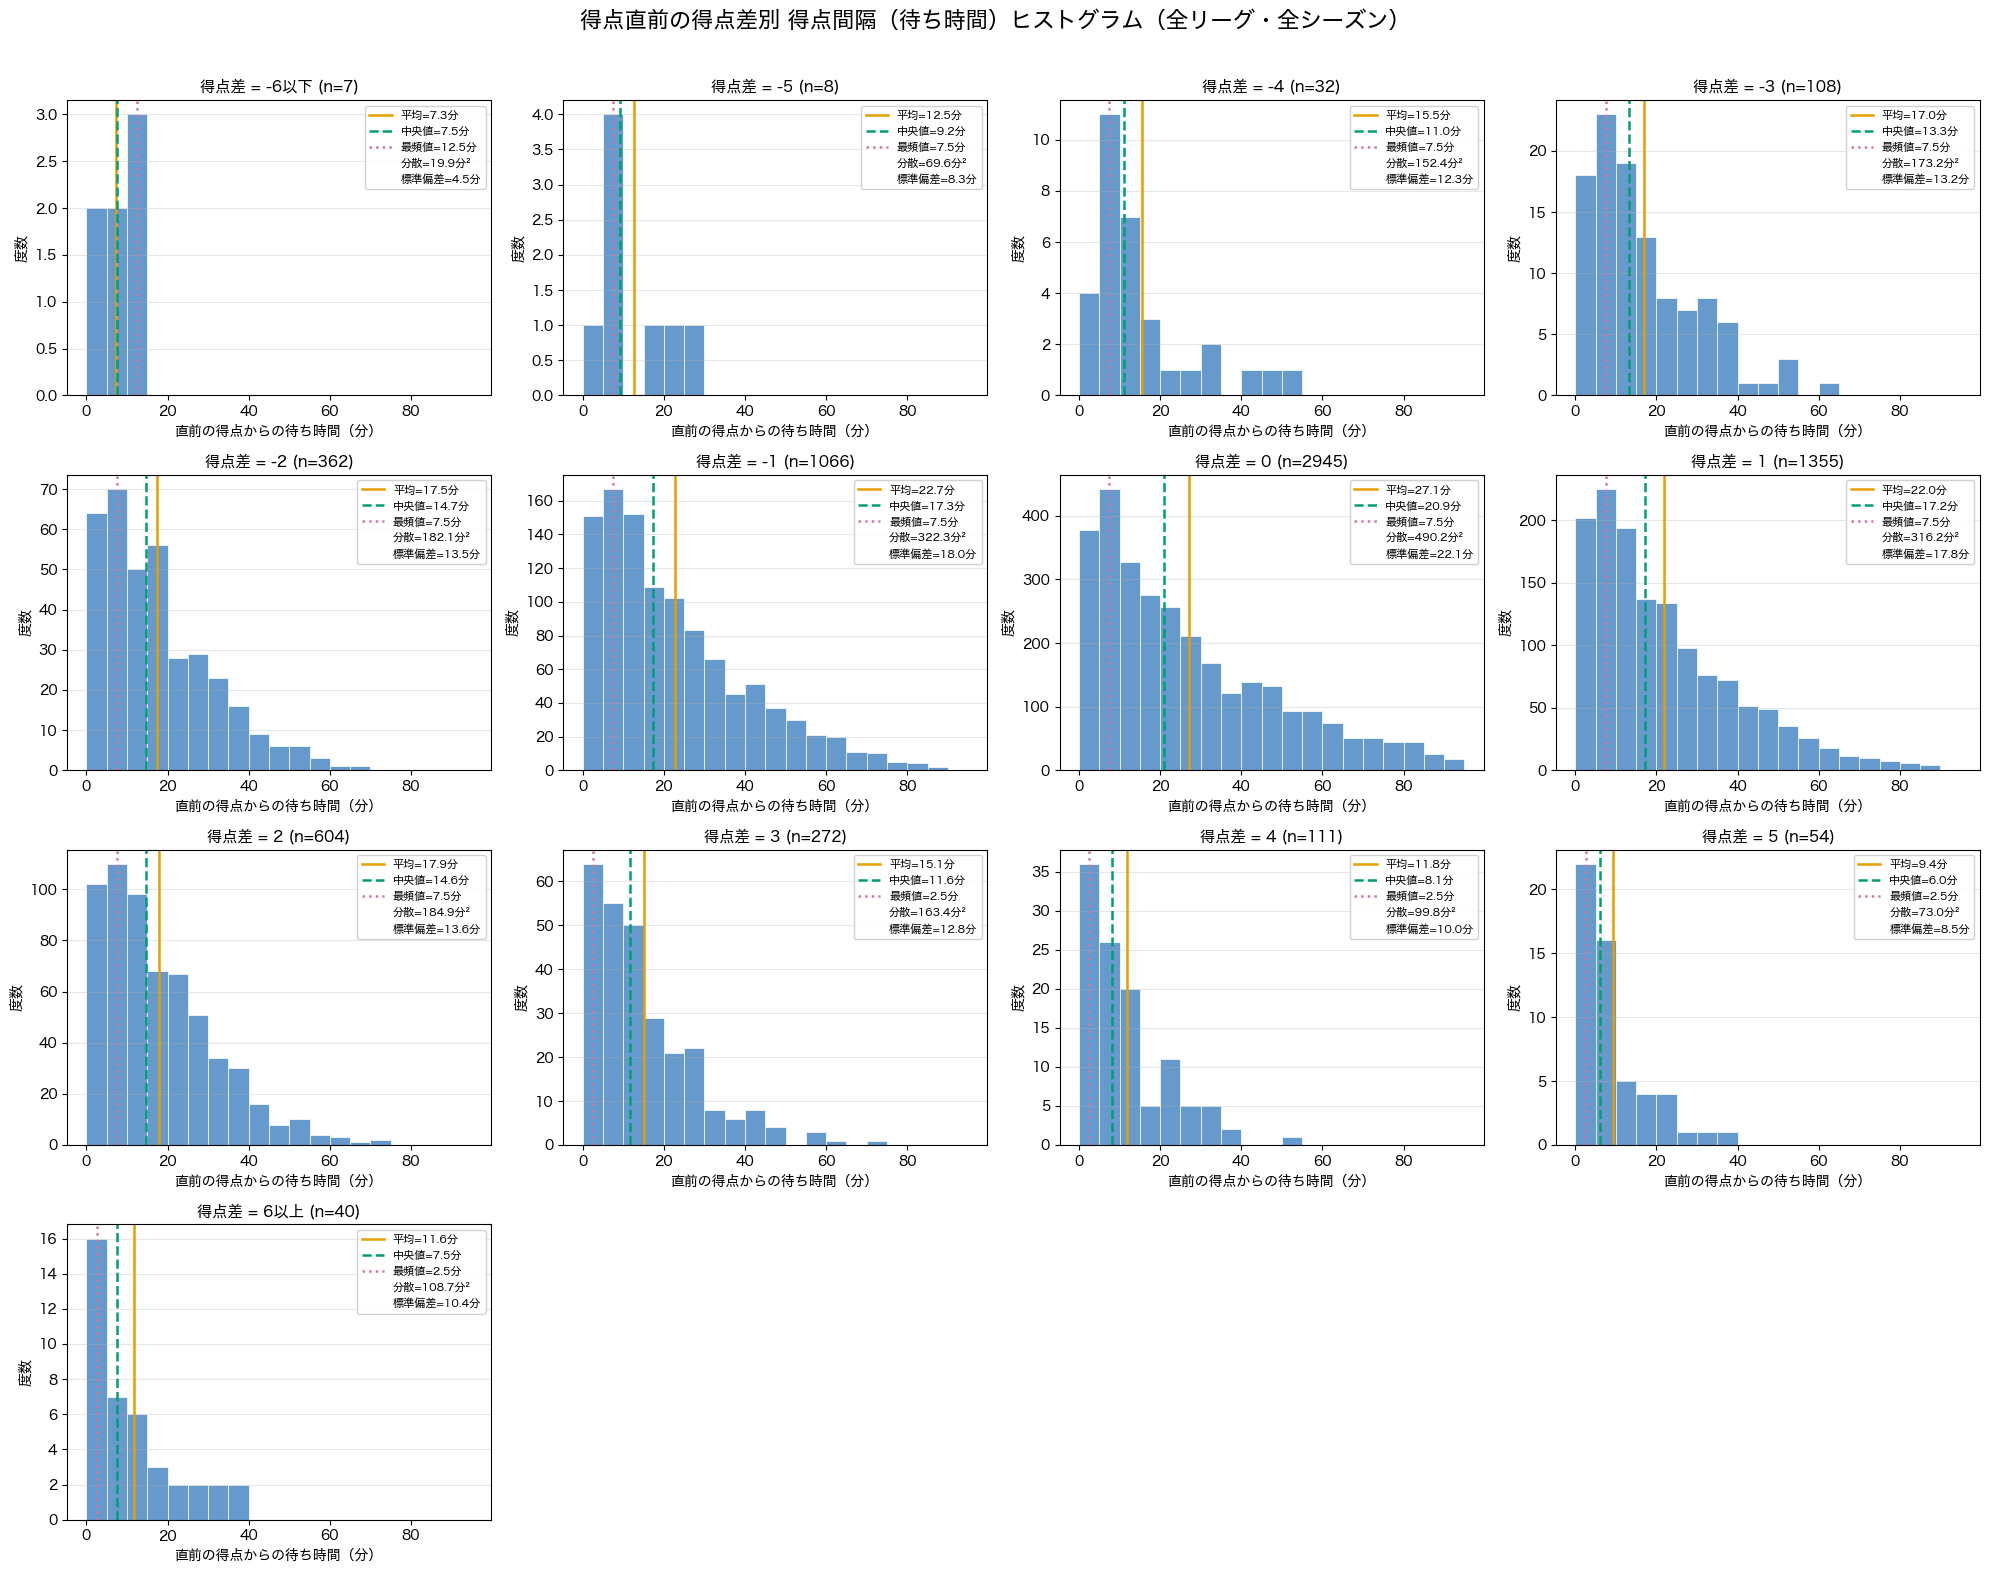

In [16]:
BAR_COLOR = "#6699CC"
MEAN_COLOR = "#E69F00"
MEDIAN_COLOR = "#009E73"
MODE_COLOR = "#CC79A7"


def compute_stats(vals, bin_edges):
    n = len(vals)
    if n == 0:
        return dict(n=0, mean=np.nan, median=np.nan, mode=np.nan, var=np.nan, std=np.nan,
                    counts=np.zeros(len(bin_edges) - 1))
    counts, _ = np.histogram(vals, bins=bin_edges)
    mode_idx = int(np.argmax(counts))
    mode_val = (bin_edges[mode_idx] + bin_edges[mode_idx + 1]) / 2
    return dict(n=n, mean=np.mean(vals), median=np.median(vals), mode=mode_val,
                var=np.var(vals), std=np.std(vals), counts=counts)


def plot_one(ax, vals, title, bin_edges):
    stats = compute_stats(vals, bin_edges)
    ax.bar(bin_edges[:-1], stats["counts"], width=BIN_WIDTH, align="edge",
           color=BAR_COLOR, edgecolor="white", linewidth=0.5)
    if stats["n"] > 0:
        ax.axvline(stats["mean"], color=MEAN_COLOR, linestyle="-", linewidth=1.8,
                    label=f"平均={stats['mean']:.1f}分")
        ax.axvline(stats["median"], color=MEDIAN_COLOR, linestyle="--", linewidth=1.8,
                    label=f"中央値={stats['median']:.1f}分")
        ax.axvline(stats["mode"], color=MODE_COLOR, linestyle=":", linewidth=1.8,
                    label=f"最頻値={stats['mode']:.1f}分")
        var_handle = Line2D([], [], color="none", label=f"分散={stats['var']:.1f}分²")
        std_handle = Line2D([], [], color="none", label=f"標準偏差={stats['std']:.1f}分")
        handles, labels = ax.get_legend_handles_labels()
        handles += [var_handle, std_handle]
        labels += [var_handle.get_label(), std_handle.get_label()]
        ax.legend(handles, labels, fontsize=8, loc="upper right", framealpha=0.9)
    ax.set_title(f"得点差 = {title} (n={stats['n']})", fontsize=11)
    ax.set_xlabel("直前の得点からの待ち時間（分）")
    ax.set_ylabel("度数")
    ax.grid(axis="y", alpha=0.3)
    return stats


fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

all_stats = {}
for i, cat in enumerate(CATEGORY_ORDER):
    vals = events_df.loc[events_df["diff_category"] == cat, "waiting_time"].values
    all_stats[cat] = plot_one(axes[i], vals, cat, BIN_EDGES)

for j in range(len(CATEGORY_ORDER), len(axes)):
    axes[j].axis("off")

fig.suptitle("得点直前の得点差別 得点間隔（待ち時間）ヒストグラム（全リーグ・全シーズン）", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/score_difference_histograms_all13.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 6. 「6以上」「-6以下」を実際の得点差の値ごとに個別に確認する

上の13分割図では「6以上」「-6以下」をそれぞれ1つの区分にまとめてしまっているため、
実際には6, 7, 8, ...（あるいは-6, -7, -8, ...）のどの値がどのくらいあるのかが分からない。
そこで、データ中に実際に出現する得点差の値（6以上・-6以下の範囲のみ）それぞれについて、
同じ集計方法・同じビン境界で個別にヒストグラムを描画する。


6以上・-6以下の範囲で実際に出現する得点差: [-11, -7, -6, 6, 7, 8, 9, 10]
保存しました: ./figures/score_difference_histograms_extreme.png


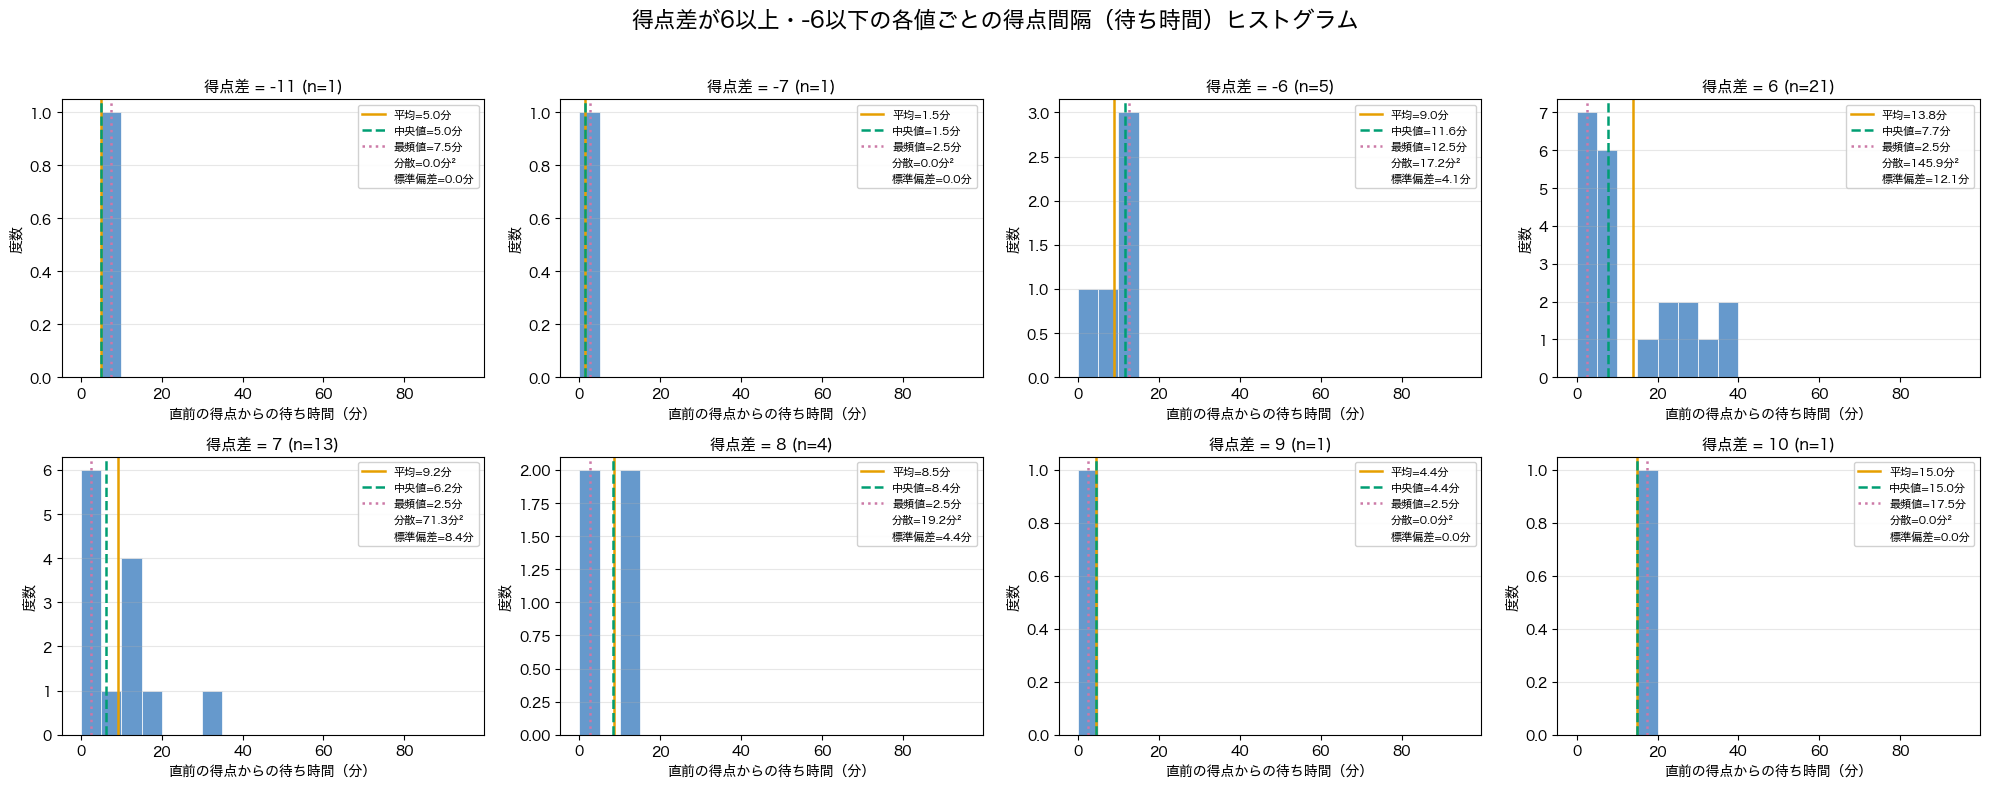

In [17]:
extreme_diffs = sorted(
    events_df.loc[(events_df["diff_before"] <= -6) | (events_df["diff_before"] >= 6), "diff_before"].unique()
)
print(f"6以上・-6以下の範囲で実際に出現する得点差: {extreme_diffs}")

n_cols = 4
n_rows = int(np.ceil(len(extreme_diffs) / n_cols))
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes2 = np.atleast_1d(axes2).flatten()

for i, d in enumerate(extreme_diffs):
    vals = events_df.loc[events_df["diff_before"] == d, "waiting_time"].values
    plot_one(axes2[i], vals, str(int(d)), BIN_EDGES)

for j in range(len(extreme_diffs), len(axes2)):
    axes2[j].axis("off")

fig2.suptitle("得点差が6以上・-6以下の各値ごとの得点間隔（待ち時間）ヒストグラム", fontsize=16)
fig2.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs("./figures", exist_ok=True)
out_path2 = "./figures/score_difference_histograms_extreme.png"
fig2.savefig(out_path2, dpi=150)
print(f"保存しました: {out_path2}")
plt.show()


## 7. Dixon & Robinson (1998) Model IVの状態区分によるヒストグラム

前節までの13区分（得点差-6以下〜6以上、得点したチーム視点）に加えて、Dixon & Robinson (1998)
の Model IV（6パラメータ版の得点差依存モデル、論文Table 2参照）で使われている7つの
状態区分でも同様の分析を行う。

Model IVは、得点 (x, y)（x=ホーム、y=アウェイの得点数）を次の7状態に分類し、それぞれの状態に
いる間のホーム・アウェイそれぞれの得点率を別パラメータで推定している。

| 状態 | 条件 |
|---|---|
| (0,0) | x=0, y=0（基準状態） |
| (1,0) | x=1, y=0 |
| (0,1) | x=0, y=1 |
| (1,1) | x=1, y=1 |
| 同点(2-2以上) | x-y=0 かつ x,y≥2 |
| リード(2点差以上関与) | x-y≥1 かつ x≥2 |
| ビハインド(2点差以上関与) | x-y≤-1 かつ y≥2 |

各得点イベントを、その得点が入る**直前の(ホーム, アウェイ)得点**からこの7区分のいずれかに
分類し、直前の得点（または試合開始）からの待ち時間を対応させたデータセット
（`model_iv_events_df`）を作る。この区分はホーム/アウェイの区別込みでスコア状態そのものを
分類するもので、6節までの「得点したチーム視点の得点差（`diff_category`）」とは定義が異なる点に
注意（例えば「ホームが1-0でリード中にアウェイが得点する」ケースは、この区分では状態(1,0)として
分類されるが、`diff_category`では得点したチーム視点で"-1"に分類される）。

ヒストグラムは、5節までと同じ規則（`BIN_EDGES`共通・平均/中央値/最頻値/分散/標準偏差を重ね表示）
に従って描画する。この`model_iv_events_df`は、この後のKaplan-Meier曲線・ログランク検定でも
そのまま使う。


In [18]:
MODEL_IV_STATE_ORDER = [
    "(0,0)", "(1,0)", "(0,1)", "(1,1)",
    "同点(2-2以上)", "リード(2点差以上関与)", "ビハインド(2点差以上関与)",
]


def classify_model_iv_state(home, away):
    """Dixon & Robinson (1998) Model IV の7状態のいずれかに (home, away) を分類する。"""
    diff = home - away
    if home == 0 and away == 0:
        return "(0,0)"
    if home == 1 and away == 0:
        return "(1,0)"
    if home == 0 and away == 1:
        return "(0,1)"
    if home == 1 and away == 1:
        return "(1,1)"
    if diff == 0 and home >= 2:
        return "同点(2-2以上)"
    if diff >= 1 and home >= 2:
        return "リード(2点差以上関与)"
    if diff <= -1 and away >= 2:
        return "ビハインド(2点差以上関与)"
    raise ValueError(f"分類できないスコア: ({home}, {away})")


def build_model_iv_events(df):
    """
    goals_and_red_cards の df から、各得点イベントについて「得点直前のホーム・アウェイ得点」を
    Model IVの7状態に分類し、直前の得点（または試合開始）からの待ち時間を対応させる。
    """
    goal_rows = df[df["red_card"].isna() & df["home_away"].notna()].copy()
    goal_rows["time_min"] = goal_rows["minute"].astype(float) + goal_rows["second"].astype(float) / 60.0
    goal_rows["home_away"] = goal_rows["home_away"].astype(int)

    records = []
    group_cols = ["league_code", "season_name", "match_id"]
    for (league_code, season_name, match_id), g in goal_rows.groupby(group_cols):
        g = g.sort_values("time_min")
        home_score = away_score = 0
        prev_t = 0.0
        for row in g.itertuples(index=False):
            t = row.time_min
            state = classify_model_iv_state(home_score, away_score)
            records.append({
                "league_code": league_code, "season_name": season_name, "match_id": match_id,
                "home_before": home_score, "away_before": away_score,
                "state": state, "waiting_time": t - prev_t,
            })
            if row.home_away == 0:
                home_score += 1
            else:
                away_score += 1
            prev_t = t

    return pd.DataFrame(records)


model_iv_events_df = build_model_iv_events(df_all)
print(f"観測数: {len(model_iv_events_df)}")
model_iv_events_df["state"].value_counts().reindex(MODEL_IV_STATE_ORDER)


観測数: 6964


state
(0,0)             2304
(1,0)             1027
(0,1)              845
(1,1)              538
同点(2-2以上)          103
リード(2点差以上関与)      1283
ビハインド(2点差以上関与)     864
Name: count, dtype: int64

保存しました: ./figures/score_difference_histograms_model4states.png


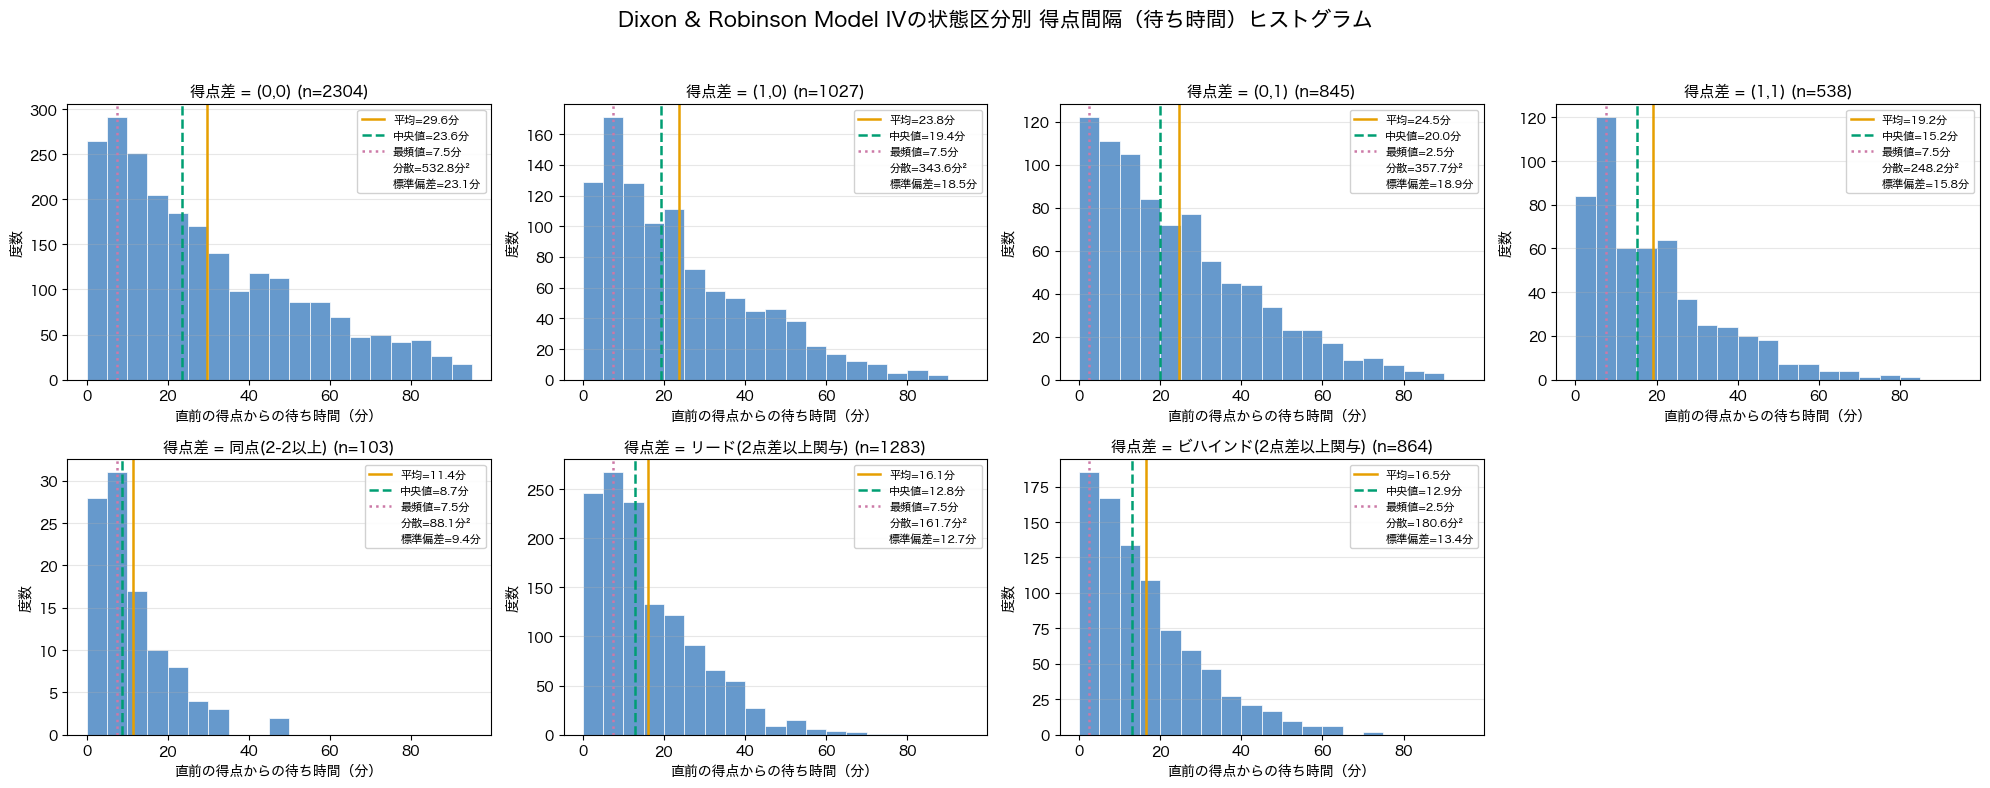

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

model_iv_stats = {}
for i, state in enumerate(MODEL_IV_STATE_ORDER):
    vals = model_iv_events_df.loc[model_iv_events_df["state"] == state, "waiting_time"].values
    model_iv_stats[state] = plot_one(axes[i], vals, state, BIN_EDGES)

for j in range(len(MODEL_IV_STATE_ORDER), len(axes)):
    axes[j].axis("off")

fig.suptitle("Dixon & Robinson Model IVの状態区分別 得点間隔（待ち時間）ヒストグラム", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/score_difference_histograms_model4states.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


## 8. Kaplan-Meier曲線とログランク検定（Model IVの状態区分）

前節で作った `model_iv_events_df`（Dixon & Robinson (1998) Model IVの7状態区分）を使って、
Kaplan-Meier曲線とログランク検定を行う。13区分（`diff_category`）で行うとログランクの
ペアワイズ組み合わせが13C2 = 78通りになり煩雑なため、ここでは7状態（7C2 = 21通り）を用いる。


保存しました: ./figures/score_difference_km_curves_model4states.png


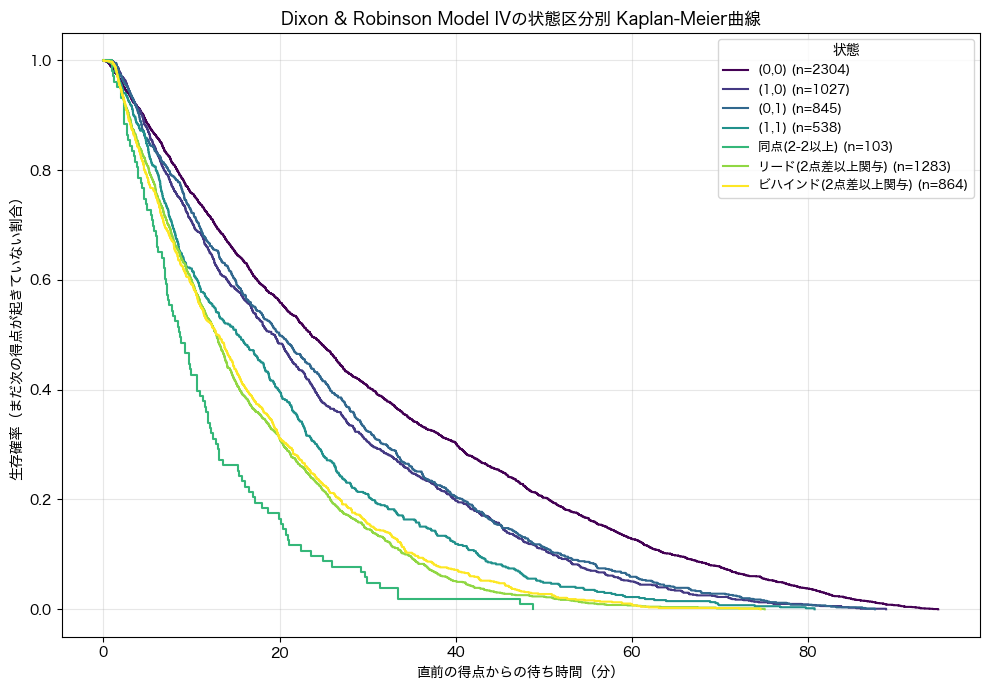

In [20]:
try:
    from lifelines import KaplanMeierFitter
except ModuleNotFoundError:
    # このノートブックのカーネルに lifelines が入っていない場合、自動でインストールする。
    # 同一プロセス内で numpy/matplotlib 等の依存が更新されると壊れることがあるため、
    # インストール後はあえて処理を止め、カーネル再起動を促す。
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "lifelines"])
    raise RuntimeError(
        "lifelines をインストールしました。numpy/matplotlib との整合性のため、"
        "カーネルを再起動してから、このセルより上から再実行してください。"
    )

fig, ax = plt.subplots(figsize=(10, 7))
kmf = KaplanMeierFitter()
colors = plt.cm.viridis(np.linspace(0, 1, len(MODEL_IV_STATE_ORDER)))

for state, color in zip(MODEL_IV_STATE_ORDER, colors):
    vals = model_iv_events_df.loc[model_iv_events_df["state"] == state, "waiting_time"].values
    if len(vals) == 0:
        continue
    kmf.fit(durations=vals, event_observed=None, label=f"{state} (n={len(vals)})")
    kmf.plot_survival_function(ax=ax, ci_show=False, color=color)

ax.set_xlabel("直前の得点からの待ち時間（分）")
ax.set_ylabel("生存確率（まだ次の得点が起きていない割合）")
ax.set_title("Dixon & Robinson Model IVの状態区分別 Kaplan-Meier曲線")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right", title="状態")
fig.tight_layout()

os.makedirs("./figures", exist_ok=True)
out_path = "./figures/score_difference_km_curves_model4states.png"
fig.savefig(out_path, dpi=150)
print(f"保存しました: {out_path}")
plt.show()


In [21]:
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

# Model IVの7状態を一括で比較するログランク検定
overall_result = multivariate_logrank_test(
    event_durations=model_iv_events_df["waiting_time"],
    groups=model_iv_events_df["state"],
)
print("=== Model IV 7状態一括のログランク検定 ===")
overall_result.print_summary()

# 状態間のペアワイズ比較（7C2 = 21通り）
pairwise_result = pairwise_logrank_test(
    event_durations=model_iv_events_df["waiting_time"],
    groups=model_iv_events_df["state"],
)

pairwise_summary = pairwise_result.summary.copy()
n_comparisons = len(pairwise_summary)
pairwise_summary["p_bonferroni"] = (pairwise_summary["p"] * n_comparisons).clip(upper=1.0)
pairwise_summary = pairwise_summary.sort_values("p")

def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

# p値そのものに有意水準の星を付けた文字列に置き換える（例: 2.352009e-26***）
pairwise_summary["p"] = pairwise_summary["p"].apply(lambda v: f"{v:.6e}{stars(v)}")
pairwise_summary["p_bonferroni"] = pairwise_summary["p_bonferroni"].apply(lambda v: f"{v:.6e}{stars(v)}")

print(f"\n=== 状態間のペアワイズ・ログランク検定（p値昇順、比較数={n_comparisons}） ===")
print("有意水準: * p<0.10, ** p<0.05, *** p<0.01")
pairwise_summary


=== Model IV 7状態一括のログランク検定 ===



=== 状態間のペアワイズ・ログランク検定（p値昇順、比較数=21） ===
有意水準: * p<0.10, ** p<0.05, *** p<0.01


test_statistic                 p    -log2(p)  \
(0,0)          リード(2点差以上関与)        462.811245  1.175222e-102***  338.603733   
               ビハインド(2点差以上関与)      326.038606   7.008093e-73***  239.691729   
(0,1)          リード(2点差以上関与)        149.249374   2.529480e-34***  111.606714   
(1,0)          リード(2点差以上関与)        141.616735   1.179465e-32***  106.063566   
(0,0)          同点(2-2以上)           137.464424   9.543785e-32***  103.047137   
               (1,1)               131.138496   2.309200e-30***   98.450450   
(0,1)          ビハインド(2点差以上関与)      107.469945   3.511910e-25***   81.235947   
(1,0)          ビハインド(2点差以上関与)       99.197645   2.285186e-23***   75.212035   
(0,1)          同点(2-2以上)            84.043319   4.840515e-20***   64.163401   
(1,0)          同点(2-2以上)            78.439572   8.248319e-19***   60.072534   
(0,0)          (1,0)                66.187462   4.100124e-16***   51.115182   
               (0,1)                44.015065   3.258582e-11***   34.836965   
(1,1)          同点(2-2以上)            33.543715   6.968018e-09***   27.096604   
(0,1)          (1,1)                31.279118   2.234705e-08***   25.415340   
(1,0)          (1,1)                25.183186   5.213475e-07***   20.871251   
(1,1)          リード(2点差以上関与)         21.441427   3.648035e-06***   18.064449   
ビハインド(2点差以上関与) 同点(2-2以上)            18.478660   1.718174e-05***   15.828765   
リード(2点差以上関与)   同点(2-2以上)            17.911432   2.314268e-05***   15.399084   
(1,1)          ビハインド(2点差以上関与)       12.814139   3.440096e-04***   11.505264   
(0,1)          (1,0)                 0.773581      3.791117e-01    1.399305   
ビハインド(2点差以上関与) リード(2点差以上関与)          0.749581      3.866090e-01    1.371053   

                                   p_bonferroni  
(0,0)          リード(2点差以上関与)    2.467966e-101***  
               ビハインド(2点差以上関与)   1.471699e-71***  
(0,1)          リード(2点差以上関与)     5.311909e-33***  
(1,0)          リード(2点差以上関与)     2.476877e-31***  
(0,0)          同点(2-2以上)        2.004195e-30***  
               (1,1)            4.849320e-29***  
(0,1)          ビハインド(2点差以上関与)   7.375010e-24***  
(1,0)          ビハインド(2点差以上関与)   4.798890e-22***  
(0,1)          同点(2-2以上)        1.016508e-18***  
(1,0)          同点(2-2以上)        1.732147e-17***  
(0,0)          (1,0)            8.610260e-15***  
               (0,1)            6.843023e-10***  
(1,1)          同点(2-2以上)        1.463284e-07***  
(0,1)          (1,1)            4.692880e-07***  
(1,0)          (1,1)            1.094830e-05***  
(1,1)          リード(2点差以上関与)     7.660873e-05***  
ビハインド(2点差以上関与) 同点(2-2以上)        3.608165e-04***  
リード(2点差以上関与)   同点(2-2以上)        4.859964e-04***  
(1,1)          ビハインド(2点差以上関与)   7.224202e-03***  
(0,1)          (1,0)               1.000000e+00  
ビハインド(2点差以上関与) リード(2点差以上関与)        1.000000e+00

## 注意点・拡張のヒント

- **試合最初の得点の「待ち時間」**は、便宜的にキックオフ（t=0）からの経過時間としている。
  「そもそも試合開始からの経過も待ち時間に含めるべきか」は分析の目的次第で見直しの余地がある。
- **最頻値**はヒストグラムのビン（5分刻み）に依存した近似値であり、ビン幅を変えると値も変わりうる。
- **得点差が6以上・-6以下の個別の値はサンプル数が非常に少なく**（データによってはn=1の値もある）、
  分布の形状の解釈には注意が必要。
- リーグ・シーズンごとの違いを見たい場合は、`events_df` に `league_code` / `season_name` を
  残しておき、`groupby` で分けて同様の集計・描画をすればよい（現状は全リーグ込みで集計している）。
